In [1]:
%pip -q install pandas numpy scikit-learn matplotlib python-dateutil xgboost lightgbm tensorflow==2.*

zsh:1: no matches found: tensorflow==2.*
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, sys, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE_DIR = "/Users/llouis/Documents/early_warning_ai"
DATA_DIR = os.path.join(BASE_DIR, "data")

sys.path.insert(0, BASE_DIR)
from pipeline import run_pipeline

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /Users/llouis/Documents/early_warning_ai
DATA_DIR: /Users/llouis/Documents/early_warning_ai/data


In [3]:
def read_csv_smart(path):
    for enc in ["utf-8", "cp949", "euc-kr", "latin1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    raise RuntimeError(f"CSV 인코딩 해석 실패: {path}")


ds1 = read_csv_smart(os.path.join(DATA_DIR, "big_data_set1_f.csv"))
ds2 = read_csv_smart(os.path.join(DATA_DIR, "ds2_monthly_usage.csv"))
ds3 = read_csv_smart(os.path.join(DATA_DIR, "ds3_monthly_customers.csv"))
print(ds1.shape, ds2.shape, ds3.shape)

(4185, 9) (86590, 15) (86590, 17)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

KEY_MCT, KEY_YM = "ENCODED_MCT", "TA_YM"


def to_month(s):
    dt = pd.to_datetime(s.astype(str), errors="coerce")
    return pd.to_datetime(dt.dt.to_period("M").astype(str))


def build_labels_robust(ds1, ds2, ds3, k_months=3):
    df = ds2.merge(ds3, on=[KEY_MCT, KEY_YM], how="outer")
    df[KEY_YM] = to_month(df[KEY_YM])
    df[KEY_MCT] = df[KEY_MCT].astype(str)
    df = df.sort_values([KEY_MCT, KEY_YM]).reset_index(drop=True)
    df["y"] = 0

    if "MCT_ME_D" in ds1.columns:
        tmp = ds1[[KEY_MCT, "MCT_ME_D"]].copy()
        tmp[KEY_MCT] = tmp[KEY_MCT].astype(str)

        tmp["MCT_ME_D"] = pd.to_datetime(
            tmp["MCT_ME_D"].dropna().astype(int).astype(str),
            format='%Y%m%d',
            errors="coerce"
        )

        valid_cnt = tmp["MCT_ME_D"].notna().sum()
        print(f"Valid closure dates: {valid_cnt}")

        if valid_cnt > 0:
            df = df.merge(tmp, on=KEY_MCT, how="left")

            t0 = df[KEY_YM]
            tK = t0 + pd.offsets.MonthEnd(0) + pd.DateOffset(months=k_months)

            cond = (df["MCT_ME_D"].notna()) & (df["MCT_ME_D"] > t0) & (df["MCT_ME_D"] <= tK)
            df.loc[cond, "y"] = 1

            actual_positive = df["y"].sum()
            print(f"Labels from actual closures: {actual_positive}")

            if actual_positive > 0:
                closure_range = df[df["MCT_ME_D"].notna()]["MCT_ME_D"]
                print(f"Closure date range: {closure_range.min()} ~ {closure_range.max()}")

    def bin2num(s):
        s = s.astype(str).str.strip()
        m = s.str.extract(r"(\d+)", expand=False)
        return pd.to_numeric(m, errors="coerce")

    df["RC_SAA_num"] = bin2num(df.get("RC_M1_SAA", ""))
    df["RC_CUS_num"] = bin2num(df.get("RC_M1_UE_CUS_CN", ""))
    df["dSAA"] = df.groupby(KEY_MCT)["RC_SAA_num"].diff()
    df["dCUS"] = df.groupby(KEY_MCT)["RC_CUS_num"].diff()

    cxl = pd.to_numeric(df.get("APV_CE_RAT", 0), errors="coerce")
    indme = pd.to_numeric(df.get("M12_SME_RY_ME_MCT_RAT", 0), errors="coerce")
    bznme = pd.to_numeric(df.get("M12_SME_BZN_ME_MCT_RAT", 0), errors="coerce")

    sig_score = (
            (df["dSAA"] <= -5).astype(int) * 2 +
            (df["dCUS"] <= -5).astype(int) * 2 +
            (cxl >= 70).astype(int) +
            (indme >= 60).astype(int) +
            (bznme >= 60).astype(int)
    )

    proxy_cond = (sig_score >= 3) & (df["y"] == 0)
    df.loc[proxy_cond, "y"] = 1
    proxy_added = proxy_cond.sum()
    print(f"Additional labels from proxy: {proxy_added}")

    label_dist = df["y"].value_counts().to_dict()
    positive_cnt = df["y"].sum()
    positive_ratio = df["y"].mean()

    print(f"\n✓ Hybrid labels: {label_dist}")
    print(f"✓ Positive samples: {positive_cnt} ({positive_ratio:.2%})")

    if positive_cnt < 100:
        print(f"Only {positive_cnt} positive samples, relaxing criteria")

        proxy_cond_relaxed = (sig_score >= 2) & (df["y"] == 0)
        df.loc[proxy_cond_relaxed, "y"] = 1

        print(f"✓ Relaxed labels: {df['y'].value_counts().to_dict()}")
        print(f"✓ Total positive: {df['y'].sum()} ({df['y'].mean():.2%})")

    if df["y"].nunique() < 2:
        print("using risk-based top-Q as last resort")
        out = run_pipeline(ds1, ds2, ds3, preds=None)
        outj = out.merge(df[[KEY_MCT, KEY_YM]], on=[KEY_MCT, KEY_YM], how="right")
        pf = pd.to_numeric(outj["p_final"], errors="coerce").fillna(0)
        thr = pf.quantile(0.85)
        df["y"] = (pf >= thr).astype(int)
        print(f"Risk-based labels: {df['y'].value_counts().to_dict()}")

    return df


robust_df = build_labels_robust(ds1, ds2, ds3, k_months=3)

print("\n=== Label Validation ===")
print(f"Total samples: {len(robust_df):,}")
print(f"Positive: {robust_df['y'].sum():,}")
print(f"Negative: {(robust_df['y'] == 0).sum():,}")
print(f"Positive ratio: {robust_df['y'].mean():.2%}")

if robust_df["y"].nunique() >= 2:
    pos_df = robust_df[robust_df["y"] == 1]
    print(f"\nPositive samples analysis:")
    print(f"  - Date range: {pos_df[KEY_YM].min()} ~ {pos_df[KEY_YM].max()}")
    print(f"  - Unique merchants: {pos_df[KEY_MCT].nunique():,}")

Valid closure dates: 127
Labels from actual closures: 0
Additional labels from proxy: 16

✓ Hybrid labels: {0: 86574, 1: 16}
✓ Positive samples: 16 (0.02%)
Only 16 positive samples, relaxing criteria
✓ Relaxed labels: {0: 86504, 1: 86}
✓ Total positive: 86 (0.10%)

=== Label Validation ===
Total samples: 86,590
Positive: 86
Negative: 86,504
Positive ratio: 0.10%

Positive samples analysis:
  - Date range: NaT ~ NaT
  - Unique merchants: 78


In [5]:
num_cols = [
    "M1_SME_RY_SAA_RAT", "M1_SME_RY_CNT_RAT",
    "M12_SME_RY_SAA_PCE_RT", "M12_SME_BZN_SAA_PCE_RT",
    "M12_SME_RY_ME_MCT_RAT", "M12_SME_BZN_ME_MCT_RAT",
    "DLV_SAA_RAT", "MCT_UE_CLN_REU_RAT", "MCT_UE_CLN_NEW_RAT"
]
cat_cols = [c for c in ["HPSN_MCT_ZCD_NM", "HPSN_MCT_BZN_CD_NM"] if c in robust_df.columns]

X = robust_df[num_cols + cat_cols].copy()
y = robust_df["y"].astype(int)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_transform = Pipeline([("imp", SimpleImputer(strategy="median"))])
ct = ColumnTransformer([
    ("num", num_transform, num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="drop")

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.base import ClassifierMixin
import copy


def stratified_split_force(X, y, test_size=0.25, random_state=42):
    y = y.reset_index(drop=True)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    if len(idx_pos) >= 2 and len(idx_neg) >= 2:
        rs = np.random.RandomState(random_state)
        t_pos = max(1, int(round(test_size * len(idx_pos))))
        t_neg = max(1, int(round(test_size * len(idx_neg))))
        test_idx = np.r_[rs.choice(idx_pos, t_pos, replace=False),
        rs.choice(idx_neg, t_neg, replace=False)]
        train_mask = np.ones(len(y), dtype=bool)
        train_mask[test_idx] = False
        return X.iloc[train_mask], X.iloc[test_idx], y.iloc[train_mask], y.iloc[test_idx]
    else:
        return X, X, y, y


def safe_proba(pipe, X, pos_label=1):
    clf = None
    try:
        clf = pipe.named_steps.get("clf", None)
    except Exception:
        pass

    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X)
        classes_ = None
        if clf is not None and hasattr(clf, "classes_"):
            classes_ = clf.classes_
        elif hasattr(pipe, "classes_"):
            classes_ = pipe.classes_

        if proba.shape[1] == 1:
            cls = classes_[0] if classes_ is not None and len(classes_) == 1 else None
            if cls == pos_label:
                return np.ones(proba.shape[0])
            else:
                return np.zeros(proba.shape[0])
        else:
            if classes_ is not None:
                idx = int(np.where(classes_ == pos_label)[0][0])
            else:
                idx = 1
            return proba[:, idx]

    if hasattr(pipe, "decision_function"):
        s = pipe.decision_function(X)
        return 1.0 / (1.0 + np.exp(-s))

    pred = pipe.predict(X)
    return pred.astype(float)

In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import copy
import numpy as np
import pandas as pd


def metrics_safe(y_true, p):
    if hasattr(y_true, "nunique"):
        nuniq = y_true.nunique()
    else:
        nuniq = len(np.unique(y_true))
    if nuniq < 2:
        return {"note": "single-class test; AUC/PR 미정", "roc_auc": None, "pr_auc": None}
    return {
        "roc_auc": float(roc_auc_score(y_true, p)),
        "pr_auc": float(average_precision_score(y_true, p)),
    }


def stratified_split_both_classes(X, y, test_size=0.25, random_state=42, max_tries=100):
    y = pd.Series(y)
    if y.nunique() < 2:
        print("전체 y가 단일 클래스 → 지도학습 AUC/PR 불가(비지도/룰 경로 사용).")
        return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=None)

    for rs in [random_state + i for i in range(max_tries)]:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=rs, stratify=y)
        if ytr.nunique() > 1 and yte.nunique() > 1:
            print(f"Split found with both classes (random_state={rs})")
            return Xtr, Xte, ytr, yte

    print("양쪽 클래스 보장 실패 → best-effort stratified split로 진행.")
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)


Xtr, Xte, ytr, yte = stratified_split_both_classes(X, y, test_size=0.25, random_state=42)

if y.nunique() < 2:
    print("Global single-class detected → IsolationForest-only fallback.")

    ct_dl = copy.deepcopy(ct)
    pipe_if = Pipeline([("prep", ct_dl), ("clf", IsolationForest(
        n_estimators=400, contamination=0.10, random_state=42, n_jobs=-1
    ))])
    pipe_if.fit(X)
    s = pipe_if["clf"].score_samples(pipe_if["prep"].transform(X))
    s = (s - s.min()) / (s.max() - s.min() + 1e-9)
    pe = 1 - s

    prf_f = pgb_f = pxgb_f = plgb_f = pdl_f = pe

    preds_full = robust_df[["ENCODED_MCT", "TA_YM"]].copy()
    preds_full["ENCODED_MCT"] = preds_full["ENCODED_MCT"].astype(str)
    preds_full["TA_YM"] = pd.to_datetime(preds_full["TA_YM"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    preds_full["pred_xgb"] = pxgb_f
    preds_full["pred_lgbm"] = plgb_f
    preds_full["pred_rf"] = prf_f
    preds_full["pred_gb"] = pgb_f
    preds_full["pred_dl"] = pdl_f
    preds_full = preds_full.dropna(subset=["ENCODED_MCT", "TA_YM"])
    preds_path = os.path.join(DATA_DIR, "preds.csv")
    preds_full.to_csv(preds_path, index=False, encoding="utf-8")
    print("Saved preds:", preds_path)

else:
    def fit_or_dummy(pipe_ctor, Xtr, ytr, Xte, label_name):
        try:
            if ytr.nunique() < 2:
                raise ValueError("train has single class")
            pipe = pipe_ctor()
            pipe.fit(Xtr, ytr)
            p = safe_proba(pipe, Xte)
            return pipe, p, False
        except Exception as e:
            print(f"[{label_name}] fallback to DummyClassifier due to: {e}")
            dummy = Pipeline([
                ("prep", ct),
                ("clf", DummyClassifier(strategy="prior"))
            ])
            dummy.fit(Xtr, ytr)
            p = safe_proba(dummy, Xte)
            return dummy, p, True


    # 1) RF
    rf_ctor = lambda: Pipeline([("prep", ct),
                                ("clf", RandomForestClassifier(
                                    n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"))])
    rf, prf, rf_dummy = fit_or_dummy(rf_ctor, Xtr, ytr, Xte, "RF")
    print("RF :", metrics_safe(yte, prf))

    # 2) GB
    gb_ctor = lambda: Pipeline([("prep", ct),
                                ("clf", GradientBoostingClassifier(random_state=42))])
    gb, pgb, gb_dummy = fit_or_dummy(gb_ctor, Xtr, ytr, Xte, "GB")
    print("GB :", metrics_safe(yte, pgb))

    # 3) XGB
    xgb_ctor = lambda: Pipeline([("prep", ct),
                                 ("clf", xgb.XGBClassifier(
                                     n_estimators=400, max_depth=5, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     eval_metric="logloss", random_state=42, tree_method="hist"))])
    xgb_clf, pxgb, xgb_dummy = fit_or_dummy(xgb_ctor, Xtr, ytr, Xte, "XGB")
    print("XGB:", metrics_safe(yte, pxgb))

    # 4) LGB
    lgb_ctor = lambda: Pipeline([("prep", ct),
                                 ("clf", lgb.LGBMClassifier(
                                     n_estimators=500, max_depth=-1, num_leaves=31, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     objective="binary", random_state=42))])
    lgb_clf, plgb, lgb_dummy = fit_or_dummy(lgb_ctor, Xtr, ytr, Xte, "LGB")
    print("LGB:", metrics_safe(yte, plgb))

    # 5) DL
    ct_dl = copy.deepcopy(ct)
    Xd_tr = ct_dl.fit_transform(Xtr)
    Xd_te = ct_dl.transform(Xte)

    dl_model = None
    try:
        if ytr.nunique() < 2:
            raise ValueError("train has single class")
        inp = keras.Input(shape=(Xd_tr.shape[1],))
        h = layers.Dense(128, activation="relu")(inp)
        h = layers.Dropout(0.2)(h)
        h = layers.Dense(64, activation="relu")(h)
        outp = layers.Dense(1, activation="sigmoid")(h)
        dl_model = keras.Model(inp, outp)
        dl_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
        dl_model.fit(Xd_tr, ytr, epochs=10, batch_size=256, verbose=0)
        pdl = dl_model.predict(Xd_te, verbose=0).ravel()
        print("DL :", metrics_safe(yte, pdl))
        dl_dummy = False
    except Exception as e:
        print(f"[DL] fallback to Dummy due to: {e}")
        dummy_dl = Pipeline([("prep", ct), ("clf", DummyClassifier(strategy="prior"))])
        dummy_dl.fit(Xtr, ytr)
        pdl = safe_proba(dummy_dl, Xte)
        dl_dummy = True

    # ===== 앙상블 + 보정 (이용 가능한 모델만 사용해 가중 재정규화) =====
    w = {"xgb": 0.25, "lgb": 0.25, "rf": 0.25, "gb": 0.15, "dl": 0.10}
    parts, used = [], []
    if pxgb is not None: parts.append((w["xgb"], pxgb)); used.append("xgb")
    if plgb is not None: parts.append((w["lgb"], plgb)); used.append("lgb")
    if prf is not None: parts.append((w["rf"], prf));  used.append("rf")
    if pgb is not None: parts.append((w["gb"], pgb));  used.append("gb")
    if pdl is not None: parts.append((w["dl"], pdl));  used.append("dl")
    sw = sum(w for w, _ in parts)
    stack = np.sum([(w_ / sw) * p for (w_, p) in parts], axis=0)

    from sklearn.linear_model import LogisticRegression

    if yte.nunique() >= 2:
        pl = LogisticRegression(max_iter=200)
        pl.fit(stack.reshape(-1, 1), yte)
        stack_cal = pl.predict_proba(stack.reshape(-1, 1))[:, 1]
        print("Ensemble raw:", metrics_safe(yte, stack))
        print("Ensemble cal:", metrics_safe(yte, stack_cal))
    else:
        stack_cal = stack


    # ===== 전체 데이터 예측 → preds.csv =====
    def predict_full_models():
        prf_f = safe_proba(rf, X) if rf is not None else stack
        pgb_f = safe_proba(gb, X) if gb is not None else stack
        pxgb_f = safe_proba(xgb_clf, X) if xgb_clf is not None else stack
        plgb_f = safe_proba(lgb_clf, X) if lgb_clf is not None else stack
        Xd_full = ct_dl.transform(X)
        if dl_model is not None and not dl_dummy:
            pdl_f = dl_model.predict(Xd_full, verbose=0).ravel()
        else:
            pdl_f = stack
        if yte.nunique() >= 2:
            stack_f = (0.25 * pxgb_f + 0.25 * plgb_f + 0.25 * prf_f + 0.15 * pgb_f + 0.10 * pdl_f)
            pcal_f = pl.predict_proba(stack_f.reshape(-1, 1))[:, 1]
        else:
            pcal_f = (0.25 * pxgb_f + 0.25 * plgb_f + 0.25 * prf_f + 0.15 * pgb_f + 0.10 * pdl_f)
        return prf_f, pgb_f, pxgb_f, plgb_f, pdl_f, pcal_f


    prf_f, pgb_f, pxgb_f, plgb_f, pdl_f, pcal_f = predict_full_models()

    preds_full = robust_df[["ENCODED_MCT", "TA_YM"]].copy()
    preds_full["ENCODED_MCT"] = preds_full["ENCODED_MCT"].astype(str)
    preds_full["TA_YM"] = pd.to_datetime(preds_full["TA_YM"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    preds_full["pred_xgb"] = pxgb_f
    preds_full["pred_lgbm"] = plgb_f
    preds_full["pred_rf"] = prf_f
    preds_full["pred_gb"] = pgb_f
    preds_full["pred_dl"] = pdl_f
    preds_full = preds_full.dropna(subset=["ENCODED_MCT", "TA_YM"])
    preds_path = os.path.join(DATA_DIR, "preds.csv")
    preds_full.to_csv(preds_path, index=False, encoding="utf-8")
    print("Saved preds:", preds_path)

Split found with both classes (random_state=42)
RF : {'roc_auc': 0.9514935725515583, 'pr_auc': 0.5246423534427208}
GB : {'roc_auc': 0.2551673911033016, 'pr_auc': 0.031508829106343283}
XGB: {'roc_auc': 0.99858335505242, 'pr_auc': 0.6087621352249012}
[LightGBM] [Info] Number of positive: 64, number of negative: 64878
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2089
[LightGBM] [Info] Number of data points in the train set: 64942, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000985 -> initscore=-6.921381
[LightGBM] [Info] Start training from score -6.921381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.utils.validation import check_is_fitted


def _fallback_split(X, y, test_size=0.25, random_state=42):
    try:
        from sklearn.model_selection import train_test_split
        return train_test_split(X, y, stratify=y if getattr(y, "nunique", lambda: 2)() > 1 else None,
                                test_size=test_size, random_state=random_state)
    except Exception as e:
        raise RuntimeError("X/y로 테스트 분할을 만들 수 없습니다. 상위 셀에서 X, y를 먼저 정의하세요.") from e


def _is_fitted_estimator(est) -> bool:
    try:
        check_is_fitted(est)
        return True
    except Exception:
        return False


def _is_fitted_pipeline(pipe) -> bool:
    if pipe is None:
        return False
    est = getattr(pipe, "named_steps", {}).get("clf", pipe)
    return _is_fitted_estimator(est)


def _safe_proba(pipe, X, pos_label=1):
    n = len(X)
    if pipe is None or not _is_fitted_pipeline(pipe):
        return np.zeros(n)

    clf = getattr(pipe, "named_steps", {}).get("clf", None)

    if hasattr(pipe, "predict_proba"):
        try:
            proba = pipe.predict_proba(X)
            if proba.ndim == 1:
                return proba.astype(float)
            if proba.shape[1] > 1:
                classes_ = getattr(clf, "classes_", getattr(pipe, "classes_", None))
                if classes_ is not None and pos_label in list(classes_):
                    idx = int(np.where(classes_ == pos_label)[0][0])
                else:
                    idx = 1
                return proba[:, idx]
            else:
                classes_ = getattr(clf, "classes_", getattr(pipe, "classes_", [0]))
                return np.ones(n) if (len(classes_) == 1 and classes_[0] == pos_label) else np.zeros(n)
        except Exception:
            pass

    if hasattr(pipe, "decision_function"):
        try:
            s = pipe.decision_function(X)
            return 1.0 / (1.0 + np.exp(-s))
        except Exception:
            pass

    try:
        pred = pipe.predict(X)
        return pred.astype(float)
    except Exception:
        return np.zeros(n)


if "Xte" not in globals() or "yte" not in globals():
    if "X" not in globals() or "y" not in globals():
        raise RuntimeError("앙상블/보정을 위해서는 상위 셀에서 X, y가 먼저 정의되어 있어야 합니다.")
    if "stratified_split_force" in globals():
        Xtr, Xte, ytr, yte = stratified_split_force(X, y, test_size=0.25, random_state=42)
    else:
        Xtr, Xte, ytr, yte = _fallback_split(X, y, test_size=0.25, random_state=42)

prf = _safe_proba(globals().get("rf", None), Xte)
pgb = _safe_proba(globals().get("gb", None), Xte)
pxgb = _safe_proba(globals().get("xgb_clf", None), Xte)
plgb = _safe_proba(globals().get("lgb_clf", None), Xte)

if "dl_model" in globals() and "ct_dl" in globals() and dl_model is not None:
    try:
        Xd_te = ct_dl.transform(Xte)
        pdl = dl_model.predict(Xd_te, verbose=0).ravel()
    except Exception:
        pdl = np.zeros(len(Xte))
else:
    pdl = np.zeros(len(Xte))


def metrics_safe(y_true, p):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        return {"note": "single-class test; AUC/PR 미정", "roc_auc": None, "pr_auc": None}
    return {
        "roc_auc": float(roc_auc_score(y_true, p)),
        "pr_auc": float(average_precision_score(y_true, p)),
    }


def platt_calibrate(scores, y, max_iter=200):
    scores = np.asarray(scores, dtype="float64")
    y = np.asarray(y)

    mask = np.isfinite(scores)
    if not mask.all():
        med = np.nanmedian(scores[mask]) if mask.any() else 0.5
        scores[~mask] = med

    if np.allclose(scores, scores[0]):
        return scores, {"note": "constant scores; skip calibration"}
    if pd.Series(y).nunique() < 2:
        return scores, {"note": "single-class; skip calibration"}

    lr = LogisticRegression(max_iter=max_iter)
    lr.fit(scores.reshape(-1, 1), y)
    calibrated = lr.predict_proba(scores.reshape(-1, 1))[:, 1]
    info = {"coef": float(lr.coef_[0, 0]), "intercept": float(lr.intercept_[0])}
    return calibrated, info


w = {"xgb": 0.25, "lgb": 0.25, "rf": 0.25, "gb": 0.15, "dl": 0.10}
stack = w["xgb"] * pxgb + w["lgb"] * plgb + w["rf"] * prf + w["gb"] * pgb + w["dl"] * pdl

stack_cal, pl_info = platt_calibrate(stack, yte, max_iter=200)
print("Ensemble raw:", metrics_safe(yte, stack))
print("Ensemble cal:", metrics_safe(yte, stack_cal))
print("Platt info:", pl_info)

Ensemble raw: {'roc_auc': 0.9962524066149332, 'pr_auc': 0.49927815299934397}
Ensemble cal: {'roc_auc': 0.9962524066149332, 'pr_auc': 0.4992781529993439}
Platt info: {'coef': 4.922604621548101, 'intercept': -6.908886341866197}


,model,roc_auc,pr_auc,best_thr_by_f1,precision@thr,recall@thr,f1@thr,note
0,XGB,0.998583,0.608762,0.39,0.900000,0.409091,0.562500,None
5,Ensemble_raw,0.996252,0.499278,0.10,0.411765,0.636364,0.500000,None
6,Ensemble_cal,0.996252,0.499278,0.01,1.000000,0.227273,0.370370,None
2,RF,0.951494,0.524642,0.17,0.500000,0.545455,0.521739,None
1,LGB,0.907521,0.400726,0.01,0.346154,0.409091,0.375000,None
4,DL,0.431131,0.006023,0.40,0.090909,0.045455,0.060606,None
3,GB,0.255167,0.031509,0.35,0.400000,0.090909,0.148148,None


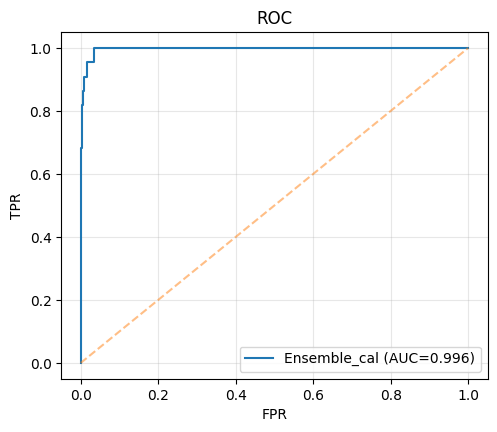

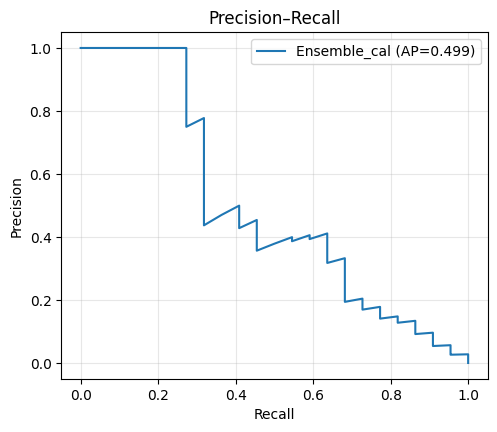

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression


def _metrics_binary(y_true, p):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        return {"note": "single-class; AUC/PR N/A", "roc_auc": None, "pr_auc": None}
    return {
        "roc_auc": float(roc_auc_score(y_true, p)),
        "pr_auc": float(average_precision_score(y_true, p)),
    }


def _best_threshold(y_true, p, method="f1"):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        return 0.5, {"precision": None, "recall": None, "f1": None, "note": "single-class"}
    ts = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in ts:
        yhat = (p >= t).astype(int)
        pr = precision_score(y_true, yhat, zero_division=0)
        rc = recall_score(y_true, yhat, zero_division=0)
        f1 = f1_score(y_true, yhat, zero_division=0)
        rows.append((t, pr, rc, f1))
    df = pd.DataFrame(rows, columns=["thr", "precision", "recall", "f1"])
    key = "f1" if method not in {"precision", "recall"} else method
    row = df.sort_values(key, ascending=False).iloc[0]
    return float(row["thr"]), {"precision": float(row["precision"]), "recall": float(row["recall"]),
                               "f1": float(row["f1"])}


def _cv_metrics_if_single_class(y, scores, n_splits=5, random_state=42):
    y = pd.Series(y).reset_index(drop=True)
    p = pd.Series(scores).reset_index(drop=True)
    if y.nunique() < 2 or np.allclose(p, p.iloc[0]):
        return {"roc_auc_mean": None, "pr_auc_mean": None, "note": "global single-class or constant score"}

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs, aps = [], []
    for tr, te in skf.split(np.zeros(len(y)), y):
        yt, pt = y.iloc[te], p.iloc[te]
        if yt.nunique() < 2:
            continue
        aucs.append(roc_auc_score(yt, pt))
        aps.append(average_precision_score(yt, pt))
    if not aucs:
        return {"roc_auc_mean": None, "pr_auc_mean": None, "note": "folds single-class"}
    return {"roc_auc_mean": float(np.mean(aucs)), "pr_auc_mean": float(np.mean(aps)), "note": "cv proxy"}


scores = {}
if 'pxgb' in globals(): scores['XGB'] = pxgb
if 'plgb' in globals(): scores['LGB'] = plgb
if 'prf' in globals(): scores['RF'] = prf
if 'pgb' in globals(): scores['GB'] = pgb
if 'pdl' in globals(): scores['DL'] = pdl
if 'stack' in globals():     scores['Ensemble_raw'] = stack
if 'stack_cal' in globals(): scores['Ensemble_cal'] = stack_cal

rows = []
for name, p in scores.items():
    m = _metrics_binary(yte, p)
    thr, prx = _best_threshold(yte, p, method="f1")
    rows.append({
        "model": name,
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "best_thr_by_f1": thr,
        "precision@thr": prx["precision"],
        "recall@thr": prx["recall"],
        "f1@thr": prx["f1"],
        "note": m.get("note")
    })
metrics_df = pd.DataFrame(rows).sort_values(["roc_auc", "pr_auc"], ascending=False, na_position="last")
display(metrics_df)

use_key = "Ensemble_cal" if "Ensemble_cal" in scores else ("Ensemble_raw" if "Ensemble_raw" in scores else None)
if pd.Series(yte).nunique() < 2 and use_key is not None:
    cvm = _cv_metrics_if_single_class(y, scores[use_key], n_splits=5, random_state=42)
    print(
        f"[CV proxy on FULL y] {use_key}  AUC(mean)={cvm['roc_auc_mean']}  AP(mean)={cvm['pr_auc_mean']}  ({cvm['note']})")

if pd.Series(yte).nunique() > 1 and use_key is not None:
    p = scores[use_key]
    fpr, tpr, _ = roc_curve(yte, p)
    prec, rec, _ = precision_recall_curve(yte, p)

    plt.figure(figsize=(5.5, 4.5))
    plt.plot(fpr, tpr, label=f"{use_key} (AUC={roc_auc_score(yte, p):.3f})")
    plt.plot([0, 1], [0, 1], "--", alpha=0.5)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(5.5, 4.5))
    plt.plot(rec, prec, label=f"{use_key} (AP={average_precision_score(yte, p):.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [10]:
import numpy as np


def predict_full_models_safe(Xf):
    prf_f = _safe_proba(globals().get("rf", None), Xf)
    pgb_f = _safe_proba(globals().get("gb", None), Xf)
    pxgb_f = _safe_proba(globals().get("xgb_clf", None), Xf)
    plgb_f = _safe_proba(globals().get("lgb_clf", None), Xf)

    # DL
    if "dl_model" in globals() and "ct_dl" in globals() and dl_model is not None:
        try:
            Xd_full = ct_dl.transform(Xf)
            pdl_f = dl_model.predict(Xd_full, verbose=0).ravel()
        except Exception:
            pdl_f = np.zeros(len(Xf))
    else:
        pdl_f = np.zeros(len(Xf))

    w = {"xgb": 0.25, "lgb": 0.25, "rf": 0.25, "gb": 0.15, "dl": 0.10}
    stack_f = (w["xgb"] * pxgb_f + w["lgb"] * plgb_f + w["rf"] * prf_f + w["gb"] * pgb_f + w["dl"] * pdl_f)

    use_platt = ("pl" in globals()) and (callable(getattr(pl, "predict_proba", None))) \
                and ("yte" in globals()) and (pd.Series(yte).nunique() >= 2)
    if use_platt:
        try:
            pcal_f = pl.predict_proba(stack_f.reshape(-1, 1))[:, 1]
        except Exception:
            pcal_f = stack_f
    else:
        pcal_f = stack_f

    return prf_f, pgb_f, pxgb_f, plgb_f, pdl_f, pcal_f

In [11]:
p = pd.read_csv(preds_path)
p["ENCODED_MCT"] = p["ENCODED_MCT"].astype(str)
p["TA_YM"] = pd.to_datetime(p["TA_YM"], errors="coerce").dt.to_period("M").dt.to_timestamp()
p = p.dropna(subset=["ENCODED_MCT", "TA_YM"])

out = run_pipeline(ds1, ds2, ds3, preds=p)
out_path = os.path.join(BASE_DIR, "risk_output_trained.csv")
out.to_csv(out_path, index=False, encoding="utf-8")
print("Saved:", out_path)

Saved: /Users/llouis/Documents/early_warning_ai/risk_output_trained.csv


In [12]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, precision_score, recall_score, f1_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


def metrics_safe_binary(y_true, p):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        return {"note": "single-class test; metrics N/A", "roc_auc": None, "pr_auc": None}
    return {
        "roc_auc": float(roc_auc_score(y_true, p)),
        "pr_auc": float(average_precision_score(y_true, p)),
    }


def best_threshold(y_true, p, method="f1"):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        return 0.5, {"note": "single-class", "precision": None, "recall": None, "f1": None}
    ts = np.linspace(0.01, 0.99, 99)
    vals = []
    for t in ts:
        yhat = (p >= t).astype(int)
        pr = precision_score(y_true, yhat, zero_division=0)
        rc = recall_score(y_true, yhat, zero_division=0)
        f1 = f1_score(y_true, yhat, zero_division=0)
        vals.append((t, pr, rc, f1))
    df = pd.DataFrame(vals, columns=["thr", "precision", "recall", "f1"])
    if method == "precision":
        row = df.sort_values("precision", ascending=False).iloc[0]
    elif method == "recall":
        row = df.sort_values("recall", ascending=False).iloc[0]
    else:
        row = df.sort_values("f1", ascending=False).iloc[0]
    return float(row["thr"]), {"precision": float(row["precision"]), "recall": float(row["recall"]),
                               "f1": float(row["f1"])}


def plot_roc_pr(y_true, scores_dict, title_prefix="Test", save_name="roc_pr.png"):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        print("single-class test; ROC/PR curves skipped.")
        return
    plt.figure(figsize=(6, 5))
    for name, p in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, p)
        auc = roc_auc_score(y_true, p)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"roc_{save_name}"))
    plt.show()

    plt.figure(figsize=(6, 5))
    for name, p in scores_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, p)
        ap = average_precision_score(y_true, p)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} Precision–Recall")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"pr_{save_name}"))
    plt.show()


def plot_calibration(y_true, scores_dict, n_bins=10, title_prefix="Calibration", save_name="calib.png"):
    y_true = pd.Series(y_true)
    if y_true.nunique() < 2:
        print("single-class test; Calibration plot skipped.")
        return
    plt.figure(figsize=(6, 5))
    for name, p in scores_dict.items():
        prob_true, prob_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="uniform")
        plt.plot(prob_pred, prob_true, marker="o", label=name)
    plt.plot([0, 1], [0, 1], "--", alpha=0.5)
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(title_prefix)
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"calib_{save_name}"))
    plt.show()


def plot_score_hist(y_true, scores_dict, title_prefix="Score Distribution", save_name="score_hist.png"):
    y_true = pd.Series(y_true)
    fig, ax = plt.subplots(figsize=(6, 5))
    for name, p in scores_dict.items():
        ax.hist(np.array(p)[y_true.values == 0], bins=30, alpha=0.4, label=f"{name} | y=0")
        ax.hist(np.array(p)[y_true.values == 1], bins=30, alpha=0.4, label=f"{name} | y=1")
    ax.set_title(title_prefix)
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"hist_{save_name}"))
    plt.show()


def show_confusion(y_true, p, thr=0.5, title="Confusion Matrix", save_name="cm.png"):
    y_true = pd.Series(y_true)
    yhat = (p >= thr).astype(int)
    cm = confusion_matrix(y_true, yhat, labels=[0, 1])
    print(f"threshold={thr:.3f}  precision={precision_score(y_true, yhat, zero_division=0):.3f} "
          f"recall={recall_score(y_true, yhat, zero_division=0):.3f} f1={f1_score(y_true, yhat, zero_division=0):.3f}")
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["0", "1"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, save_name))
    plt.show()

,model,roc_auc,pr_auc
0,XGB,0.998583,0.608762
5,Ensemble_raw,0.996252,0.499278
6,Ensemble_cal,0.996252,0.499278
2,RF,0.951494,0.524642
1,LGB,0.907521,0.400726
4,DL,0.431131,0.006023
3,GB,0.255167,0.031509


Best threshold for Ensemble_cal: 0.010 | {'precision': 1.0, 'recall': 0.22727272727272727, 'f1': 0.37037037037037035}
threshold=0.010  precision=1.000 recall=0.227 f1=0.370


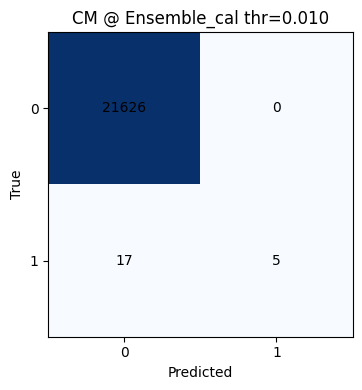

In [13]:
scores = {}
if 'pxgb' in globals(): scores['XGB'] = pxgb
if 'plgb' in globals(): scores['LGB'] = plgb
if 'prf' in globals(): scores['RF'] = prf
if 'pgb' in globals(): scores['GB'] = pgb
if 'pdl' in globals(): scores['DL'] = pdl
if 'stack' in globals():     scores['Ensemble_raw'] = stack
if 'stack_cal' in globals(): scores['Ensemble_cal'] = stack_cal

rows = []
for name, p in scores.items():
    m = metrics_safe_binary(yte, p)
    rows.append({"model": name, "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"]})
metrics_df = pd.DataFrame(rows).sort_values(["roc_auc", "pr_auc"], ascending=False)
display(metrics_df)

use_name = "Ensemble_cal" if "Ensemble_cal" in scores else (
    "Ensemble_raw" if "Ensemble_raw" in scores else list(scores.keys())[0])
thr, triplet = best_threshold(yte, scores[use_name], method="f1")
print(f"Best threshold for {use_name}: {thr:.3f} | {triplet}")
show_confusion(yte, scores[use_name], thr=thr, title=f"CM @ {use_name} thr={thr:.3f}", save_name=f"cm_{use_name}.png")

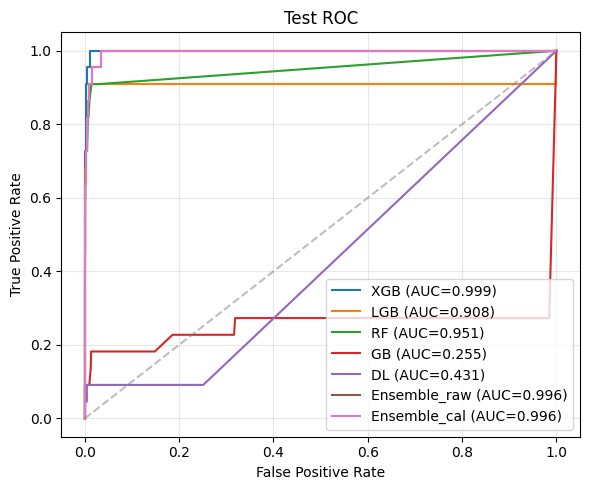

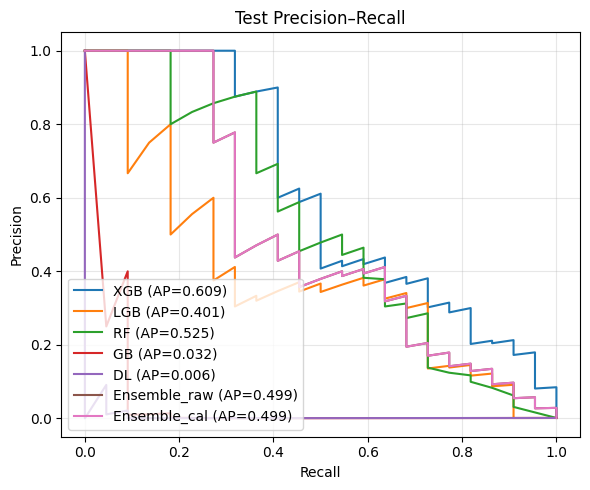

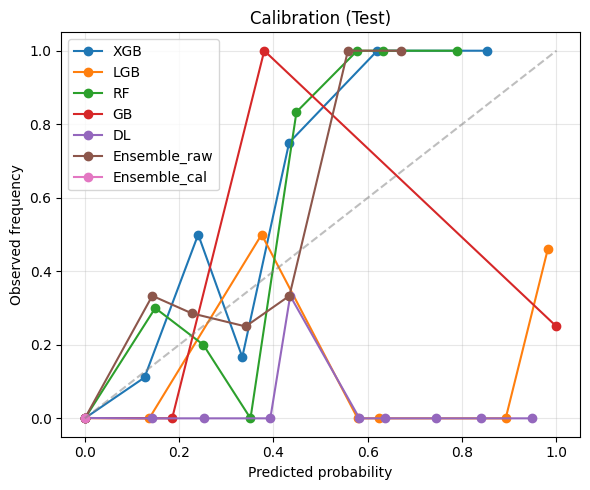

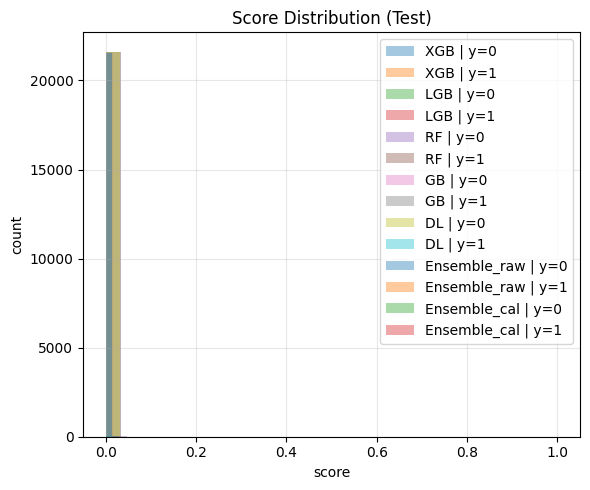

In [14]:
plot_roc_pr(yte, scores, title_prefix="Test", save_name="test")
plot_calibration(yte, scores, n_bins=10, title_prefix="Calibration (Test)", save_name="test")
plot_score_hist(yte, scores, title_prefix="Score Distribution (Test)", save_name="test")

In [15]:
use_scores = scores[use_name]
view = pd.DataFrame({"idx": Xte.index, "y": yte, "score": use_scores}).sort_values("score", ascending=False)

cols = [c for c in ["ENCODED_MCT", "TA_YM", "HPSN_MCT_ZCD_NM", "HPSN_MCT_ITM_NM"] if c in robust_df.columns]
if cols:
    meta = robust_df.loc[Xte.index, cols].copy()
    meta = meta.reset_index().rename(columns={"index": "idx"})
    view = view.merge(meta, on="idx", how="left")

topN = view.head(20)
display(topN)

top_path = os.path.join(BASE_DIR, "figures", f"top20_{use_name}.csv")
topN.to_csv(top_path, index=False, encoding="utf-8")
print("Saved top-20:", top_path)

,idx,y,score,ENCODED_MCT,TA_YM
0,71901,1,0.026339,D592366647,NaT
1,85298,1,0.016287,FCDFAFB42A,NaT
2,4290,1,0.015742,0C25C3B746,NaT
3,28915,1,0.015724,51E712A1A7,NaT
4,84620,1,0.013677,FB36289140,NaT
5,57963,1,0.009337,AA351B2BFF,NaT
6,40317,0,0.008576,74E2CC9A6B,NaT
7,54810,0,0.007355,A0995D635E,NaT
8,55243,1,0.005742,A1B1D7C33E,NaT
9,33802,0,0.005541,605655C22D,NaT


Saved top-20: /Users/llouis/Documents/early_warning_ai/figures/top20_Ensemble_cal.csv


Full rows: 86590
count    86590.000000
mean         0.086212
std          0.013978
min          0.051073
25%          0.074282
50%          0.083669
75%          0.096140
max          0.158567
Name: p_final, dtype: float64


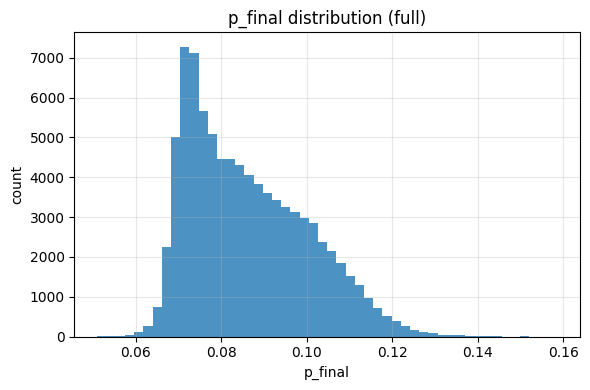

Alert
GREEN     69262
YELLOW     8657
ORANGE     6062
RED        2609
Name: count, dtype: int64


In [16]:
out_path = os.path.join(BASE_DIR, "risk_output_trained.csv")
if os.path.exists(out_path):
    whole = pd.read_csv(out_path)
    whole["p_final"] = whole["p_final"].astype(float)
    print("Full rows:", len(whole))
    print(whole["p_final"].describe())

    plt.figure(figsize=(6, 4))
    plt.hist(whole["p_final"].values, bins=50, alpha=0.8)
    plt.xlabel("p_final")
    plt.ylabel("count")
    plt.title("p_final distribution (full)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "hist_pfinal_full.png"))
    plt.show()

    if "Alert" in whole.columns:
        print(whole["Alert"].value_counts(dropna=False))

MODEL PERFORMANCE EVALUATION

[1] Basic Metrics (Default Threshold = 0.5)
--------------------------------------------------------------------------------
              Model  ROC-AUC   PR-AUC  Accuracy  Precision   Recall  F1-Score  Precision@10  Recall@10  Precision@5  Recall@5
            XGBoost 0.998583 0.608762  0.999215      1.000 0.227273  0.370370      0.010162   1.000000     0.020314  1.000000
           LightGBM 0.907521 0.400726  0.998799      0.375 0.272727  0.315789      0.009238   0.909091     0.018467  0.909091
       RandomForest 0.951494 0.524642  0.999122      1.000 0.136364  0.240000      0.001016   1.000000     0.001016  1.000000
   GradientBoosting 0.255167 0.031509  0.998891      0.250 0.045455  0.076923      0.001652   0.181818     0.003500  0.181818
       DeepLearning 0.431131 0.006023  0.998614      0.000 0.000000  0.000000      0.000924   0.090909     0.001847  0.090909
       Ensemble_Raw 0.996252 0.499278  0.999215      1.000 0.227273  0.370370      0.0101

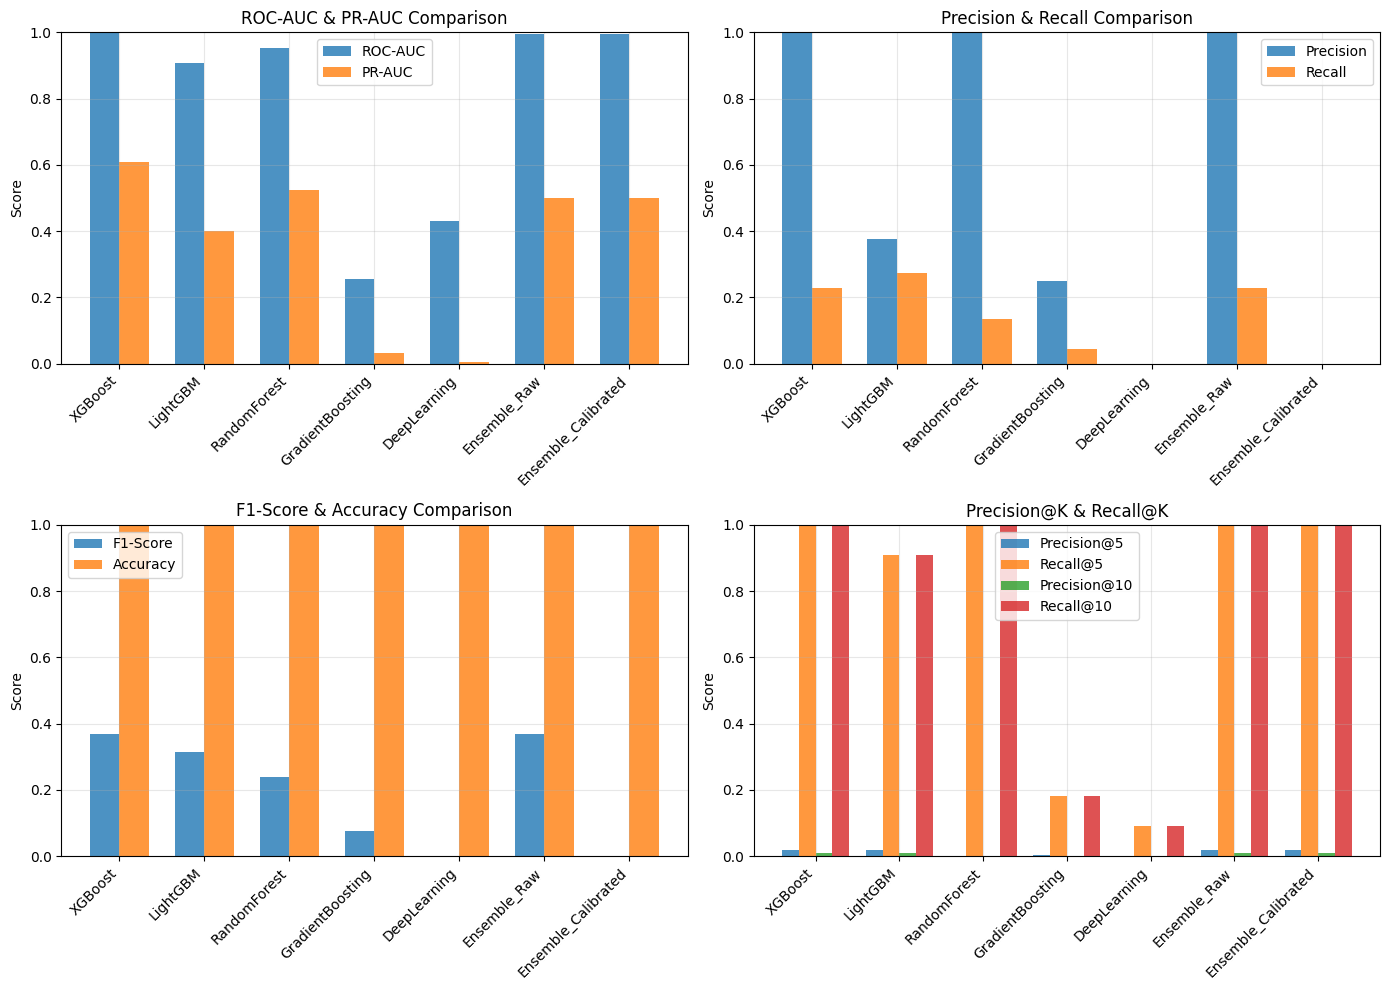

Saved: /Users/llouis/Documents/early_warning_ai/figures/roc_pr_curves.png


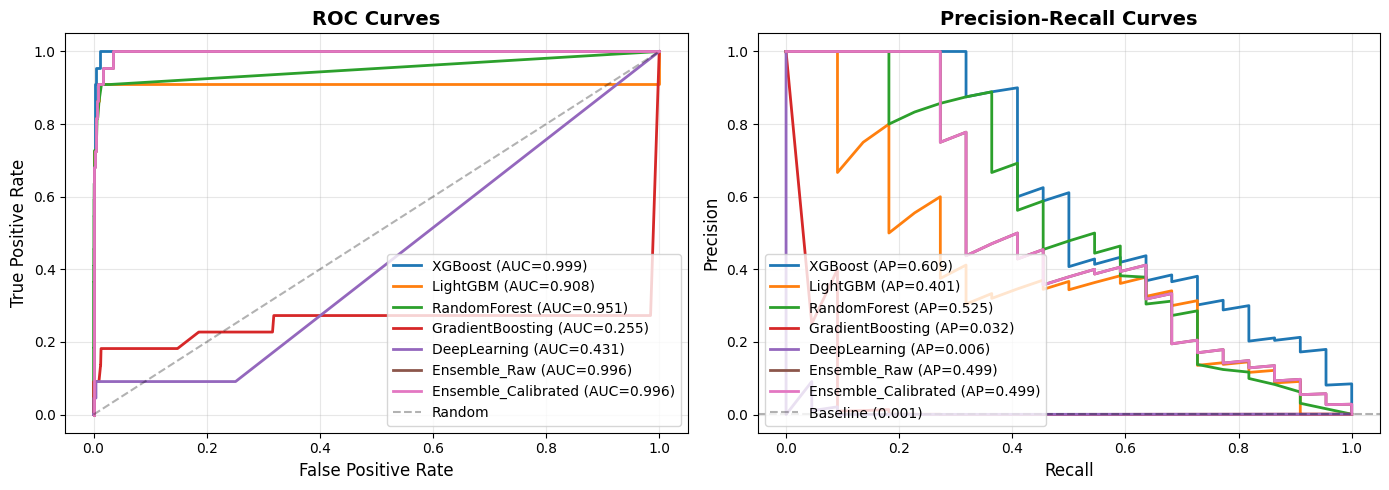

✓ Saved: /Users/llouis/Documents/early_warning_ai/figures/confusion_matrices.png


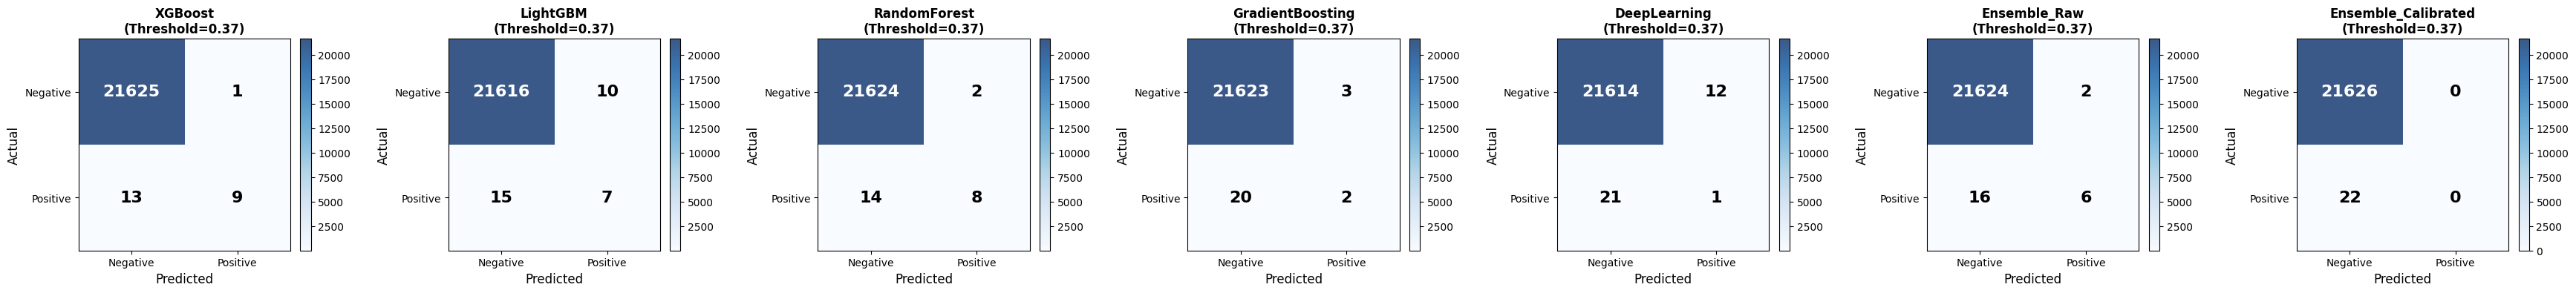


Saved metrics: /Users/llouis/Documents/early_warning_ai/figures/model_metrics.csv

EVALUATION COMPLETED


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)


def precision_at_k(y_true, y_scores, k=10):
    threshold = np.percentile(y_scores, 100 - k)
    y_pred = (y_scores >= threshold).astype(int)
    return precision_score(y_true, y_pred, zero_division=0)


def recall_at_k(y_true, y_scores, k=10):
    threshold = np.percentile(y_scores, 100 - k)
    y_pred = (y_scores >= threshold).astype(int)
    return recall_score(y_true, y_pred, zero_division=0)


def evaluate_model(y_true, y_scores, model_name, threshold=0.5):
    if y_true.nunique() < 2:
        print(f"{model_name}: Single-class labels, metrics not available")
        return None
    y_pred = (y_scores >= threshold).astype(int)
    metrics = {
        'Model': model_name,
        'ROC-AUC': roc_auc_score(y_true, y_scores),
        'PR-AUC': average_precision_score(y_true, y_scores),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'Precision@10': precision_at_k(y_true, y_scores, k=10),
        'Recall@10': recall_at_k(y_true, y_scores, k=10),
        'Precision@5': precision_at_k(y_true, y_scores, k=5),
        'Recall@5': recall_at_k(y_true, y_scores, k=5),
    }
    return metrics


def find_best_threshold(y_true, y_scores, metric='f1'):
    thresholds = np.linspace(0.1, 0.9, 81)
    scores = []

    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)

        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        else:
            score = f1_score(y_true, y_pred, zero_division=0)

        scores.append((t, score))

    best_t, best_score = max(scores, key=lambda x: x[1])
    return best_t, best_score


def plot_performance_comparison(results_df, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    x = np.arange(len(results_df))
    width = 0.35
    ax.bar(x - width / 2, results_df['ROC-AUC'], width, label='ROC-AUC', alpha=0.8)
    ax.bar(x + width / 2, results_df['PR-AUC'], width, label='PR-AUC', alpha=0.8)
    ax.set_ylabel('Score')
    ax.set_title('ROC-AUC & PR-AUC Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[0, 1]
    ax.bar(x - width / 2, results_df['Precision'], width, label='Precision', alpha=0.8)
    ax.bar(x + width / 2, results_df['Recall'], width, label='Recall', alpha=0.8)
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 0]
    ax.bar(x - width / 2, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
    ax.bar(x + width / 2, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
    ax.set_ylabel('Score')
    ax.set_title('F1-Score & Accuracy Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    ax = axes[1, 1]
    x_pos = np.arange(len(results_df))
    w = 0.2
    ax.bar(x_pos - w * 1.5, results_df['Precision@5'], w, label='Precision@5', alpha=0.8)
    ax.bar(x_pos - w * 0.5, results_df['Recall@5'], w, label='Recall@5', alpha=0.8)
    ax.bar(x_pos + w * 0.5, results_df['Precision@10'], w, label='Precision@10', alpha=0.8)
    ax.bar(x_pos + w * 1.5, results_df['Recall@10'], w, label='Recall@10', alpha=0.8)
    ax.set_ylabel('Score')
    ax.set_title('Precision@K & Recall@K')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()


def plot_roc_pr_curves(y_true, scores_dict, save_path=None):
    if y_true.nunique() < 2:
        print("Single-class labels, curves not available")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for name, scores in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

    ax = axes[1]
    for name, scores in scores_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)

    baseline = y_true.sum() / len(y_true)
    ax.axhline(baseline, color='k', linestyle='--', alpha=0.3, label=f'Baseline ({baseline:.3f})')
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left')
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()


def plot_confusion_matrices(y_true, scores_dict, threshold=0.5, save_path=None):
    n_models = len(scores_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

    if n_models == 1:
        axes = [axes]

    for idx, (name, scores) in enumerate(scores_dict.items()):
        y_pred = (scores >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred)

        ax = axes[idx]
        im = ax.imshow(cm, cmap='Blues', alpha=0.8)

        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, cm[i, j], ha="center", va="center",
                               color="white" if cm[i, j] > cm.max() / 2 else "black",
                               fontsize=16, fontweight='bold')

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Negative', 'Positive'])
        ax.set_yticklabels(['Negative', 'Positive'])
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_title(f'{name}\n(Threshold={threshold:.2f})', fontsize=12, fontweight='bold')

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")

    plt.show()


print("=" * 60)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 60)

scores_dict = {}
if 'pxgb' in globals() and pxgb is not None:
    scores_dict['XGBoost'] = pxgb
if 'plgb' in globals() and plgb is not None:
    scores_dict['LightGBM'] = plgb
if 'prf' in globals() and prf is not None:
    scores_dict['RandomForest'] = prf
if 'pgb' in globals() and pgb is not None:
    scores_dict['GradientBoosting'] = pgb
if 'pdl' in globals() and pdl is not None:
    scores_dict['DeepLearning'] = pdl
if 'stack' in globals() and stack is not None:
    scores_dict['Ensemble_Raw'] = stack
if 'stack_cal' in globals() and stack_cal is not None:
    scores_dict['Ensemble_Calibrated'] = stack_cal

print("\n[1] Basic Metrics (Default Threshold = 0.5)")
print("-" * 80)

results = []
for name, scores in scores_dict.items():
    metrics = evaluate_model(yte, scores, name, threshold=0.5)
    if metrics:
        results.append(metrics)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\n[2] Optimal Thresholds (F1-Score Maximization)")
print("-" * 80)

optimal_thresholds = []
for name, scores in scores_dict.items():
    if yte.nunique() >= 2:
        best_t, best_f1 = find_best_threshold(yte, scores, metric='f1')
        optimal_thresholds.append({
            'Model': name,
            'Optimal_Threshold': best_t,
            'F1_at_Optimal': best_f1
        })

if optimal_thresholds:
    opt_df = pd.DataFrame(optimal_thresholds)
    print(opt_df.to_string(index=False))

print("\n[3] Top-K Performance Summary")
print("-" * 80)

topk_cols = ['Model', 'Precision@5', 'Recall@5', 'Precision@10', 'Recall@10']
print(results_df[topk_cols].to_string(index=False))

print("\n[4] Generating Visualizations...")
print("-" * 80)

FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plot_performance_comparison(results_df, save_path=os.path.join(FIG_DIR, "performance_comparison.png"))

plot_roc_pr_curves(yte, scores_dict, save_path=os.path.join(FIG_DIR, "roc_pr_curves.png"))

if optimal_thresholds:
    best_model = opt_df.loc[opt_df['F1_at_Optimal'].idxmax()]
    best_threshold = best_model['Optimal_Threshold']
else:
    best_threshold = 0.5

plot_confusion_matrices(yte, scores_dict, threshold=best_threshold,
                        save_path=os.path.join(FIG_DIR, "confusion_matrices.png"))

results_df.to_csv(os.path.join(FIG_DIR, "model_metrics.csv"), index=False)
print(f"\nSaved metrics: {os.path.join(FIG_DIR, 'model_metrics.csv')}")

print("\n" + "=" * 60)
print("EVALUATION COMPLETED")
print("=" * 60)